In [5]:
# ==============================
# Install Required Libraries
# ==============================

!pip install xgboost lightgbm catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [6]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

import joblib

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [7]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

import joblib

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [8]:
# ==========================================
# Upload Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [11]:
# ==========================================
# Unzip Dataset
# ==========================================

import zipfile
import os

# Unzip the archive
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print('Archive unzipped successfully to /content/dataset!')

Archive unzipped successfully to /content/dataset!


In [31]:
# Assuming the dataset is a CSV file inside the unzipped folder.
# Let's find the CSV file in the unzipped directory.

import os

dataset_path = '/content/dataset'
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

if csv_files:
    # Assuming there's only one CSV or the first one is the main dataset
    data_file = os.path.join(dataset_path, csv_files[0])
    df = pd.read_csv(data_file)
    print(f'Successfully loaded {csv_files[0]} into DataFrame.')
    display(df.head())
else:
    print('No CSV files found in the unzipped directory.')

Successfully loaded train.csv into DataFrame.


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [14]:
# ==========================================
# Load Dataset
# ==========================================

train_df = pd.read_csv("/content/dataset/train.csv")
test_df = pd.read_csv("/content/dataset/test.csv")

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

Training Dataset Shape : (100000, 28)
Testing Dataset Shape  : (50000, 27)


In [15]:
# Display first five rows

train_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [16]:
# Dataset Information

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [17]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,100000,100000,0x25fb6,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,100000,12500,CUS_0x942c,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,100000,8,January,12500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,90015,10139,Langep,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,100000,1788,38,2833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSN,100000,12501,#F%$D@*&8,5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,100000,16,_______,7062,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,100000,18940,20867.67,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Inhand_Salary,84998.0,NaN,NaN,NaN,4194.17085,3183.686167,303.645417,1625.568229,3093.745,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,NaN,NaN,NaN,17.09128,117.404834,-1.0,3.0,6.0,7.0,1798.0


In [18]:
# Check Missing Values

missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
Monthly_Inhand_Salary,15002
Type_of_Loan,11408
Name,9985
Credit_History_Age,9030
Num_of_Delayed_Payment,7002
Amount_invested_monthly,4479
Num_Credit_Inquiries,1965
Monthly_Balance,1200


In [19]:
print("Duplicate Rows :", train_df.duplicated().sum())

Duplicate Rows : 0


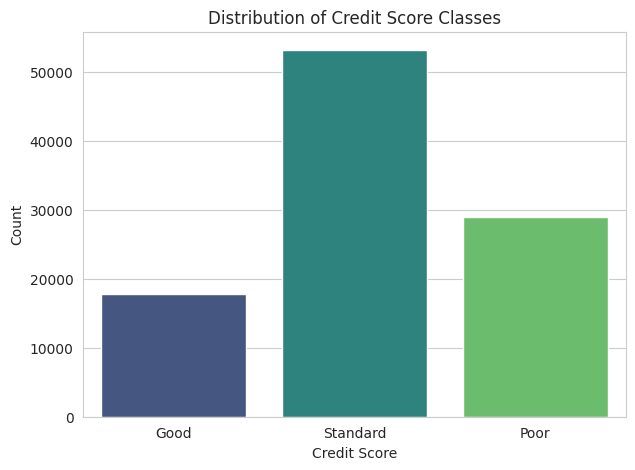

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=train_df,
    x="Credit_Score",
    palette="viridis"
)

plt.title("Distribution of Credit Score Classes")

plt.xlabel("Credit Score")

plt.ylabel("Count")

plt.show()

In [21]:
train_df.select_dtypes(include=np.number).columns

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

In [22]:
train_df.select_dtypes(include="object").columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [23]:
# ==========================================
# Remove Unnecessary Columns
# ==========================================

drop_columns = [
    "ID",
    "Customer_ID",
    "Name",
    "SSN"
]

train_df.drop(columns=drop_columns, inplace=True)
test_df.drop(columns=drop_columns, inplace=True)

print("Columns Removed Successfully!")
print(train_df.shape)

Columns Removed Successfully!
(100000, 24)


In [24]:
# ==========================================
# Replace Invalid Values
# ==========================================

train_df.replace(
    ["_", "_______", ""],
    np.nan,
    inplace=True
)

test_df.replace(
    ["_", "_______", ""],
    np.nan,
    inplace=True
)

print("Invalid Values Replaced!")

Invalid Values Replaced!


In [25]:
# ==========================================
# Convert Numeric Columns
# ==========================================

numeric_columns = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_columns:

    train_df[col] = (
        train_df[col]
        .astype(str)
        .str.replace("_","",regex=False)
    )

    train_df[col] = pd.to_numeric(
        train_df[col],
        errors="coerce"
    )

    test_df[col] = (
        test_df[col]
        .astype(str)
        .str.replace("_","",regex=False)
    )

    test_df[col] = pd.to_numeric(
        test_df[col],
        errors="coerce"
    )

print("Numeric Columns Cleaned!")

Numeric Columns Cleaned!


In [26]:
# ==========================================
# Missing Values
# ==========================================

missing = train_df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(
    ascending=False
)

,0
Credit_Mix,20195
Monthly_Inhand_Salary,15002
Type_of_Loan,11408
Credit_History_Age,9030
Occupation,7062
Num_of_Delayed_Payment,7002
Amount_invested_monthly,4479
Changed_Credit_Limit,2091
Num_Credit_Inquiries,1965
Monthly_Balance,1200


In [27]:
# ==========================================
# Fill Missing Numerical Values
# ==========================================

numerical_features = train_df.select_dtypes(
    include=np.number
).columns

imputer_num = SimpleImputer(
    strategy="median"
)

train_df[numerical_features] = imputer_num.fit_transform(
    train_df[numerical_features]
)

test_df[numerical_features] = imputer_num.transform(
    test_df[numerical_features]
)

print("Numerical Missing Values Filled!")

Numerical Missing Values Filled!


In [28]:
# ==========================================
# Fill Missing Categorical Values
# ==========================================

categorical_features = train_df.select_dtypes(
    include="object"
).columns

categorical_features = categorical_features.drop(
    "Credit_Score"
)

imputer_cat = SimpleImputer(
    strategy="most_frequent"
)

train_df[categorical_features] = imputer_cat.fit_transform(
    train_df[categorical_features]
)

test_df[categorical_features] = imputer_cat.transform(
    test_df[categorical_features]
)

print("Categorical Missing Values Filled!")

Categorical Missing Values Filled!


In [29]:
# ==========================================
# Encode Target Variable
# ==========================================

label_target = LabelEncoder()

train_df["Credit_Score"] = label_target.fit_transform(
    train_df["Credit_Score"]
)

print(label_target.classes_)

['Good' 'Poor' 'Standard']


In [30]:
# ==========================================
# Encode Categorical Features
# ==========================================

encoders = {}

for column in categorical_features:

    encoder = LabelEncoder()

    # Combine unique values from both train and test for the current column
    # to ensure the encoder sees all possible categories.
    combined_values = pd.concat([train_df[column].astype(str), test_df[column].astype(str)], axis=0).unique()

    # Fit the encoder on all unique values from both datasets
    encoder.fit(combined_values)

    # Transform both train and test data using the fitted encoder
    train_df[column] = encoder.transform(train_df[column].astype(str))
    test_df[column] = encoder.transform(test_df[column].astype(str))

    encoders[column] = encoder

print("Categorical Features Encoded!")

Categorical Features Encoded!


In [33]:
# Define features (X) and target (y)
X = train_df.drop('Credit_Score', axis=1)
y = train_df['Credit_Score']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (100000, 23)
Target (y) shape: (100000,)


In [34]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_valid, y_train, y_valid = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_valid.shape)


(80000, 23)
(20000, 23)


In [35]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_valid = scaler.transform(
    X_valid
)

X_test = scaler.transform(
    test_df
)

print("Scaling Completed!")

Scaling Completed!


In [36]:
# ==========================================
# Train Models
# ==========================================

# Initialize classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

trained_models = {}

for name, classifier in classifiers.items():
    print(f"Training {name}...")
    classifier.fit(X_train, y_train)
    trained_models[name] = classifier
    print(f"{name} trained successfully!")

print("All models trained and stored in 'trained_models' dictionary.")

Training Logistic Regression...
Logistic Regression trained successfully!
Training Decision Tree...
Decision Tree trained successfully!
Training Random Forest...
Random Forest trained successfully!
Training Gradient Boosting...
Gradient Boosting trained successfully!
Training XGBoost...
XGBoost trained successfully!
All models trained and stored in 'trained_models' dictionary.


In [37]:
# ==========================================
# Save Preprocessing Objects
# ==========================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    label_target,
    "label_encoder.pkl"
)

print("Preprocessing Objects Saved!")

Preprocessing Objects Saved!


In [38]:
# ==========================================
# Save Preprocessing Objects
# ==========================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    label_target,
    "label_encoder.pkl"
)

print("Preprocessing Objects Saved!")

Preprocessing Objects Saved!


In [39]:
# ==========================================
# Evaluate Models
# ==========================================

results = []

for name, model in trained_models.items():

    prediction = model.predict(X_valid)

    accuracy = accuracy_score(
        y_valid,
        prediction
    )

    precision = precision_score(
        y_valid,
        prediction,
        average="weighted"
    )

    recall = recall_score(
        y_valid,
        prediction,
        average="weighted"
    )

    f1 = f1_score(
        y_valid,
        prediction,
        average="weighted"
    )

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1

    ])

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.58895,0.583138,0.58895,0.573308
1,Decision Tree,0.68235,0.682782,0.68235,0.682555
2,Random Forest,0.78630,0.786002,0.78630,0.786063
3,Gradient Boosting,0.69795,0.698844,0.69795,0.697139
4,XGBoost,0.75330,0.753066,0.75330,0.753112


In [40]:
# ==========================================
# Sort Model Performance
# ==========================================

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.78630,0.786002,0.78630,0.786063
1,XGBoost,0.75330,0.753066,0.75330,0.753112
2,Gradient Boosting,0.69795,0.698844,0.69795,0.697139
3,Decision Tree,0.68235,0.682782,0.68235,0.682555
4,Logistic Regression,0.58895,0.583138,0.58895,0.573308


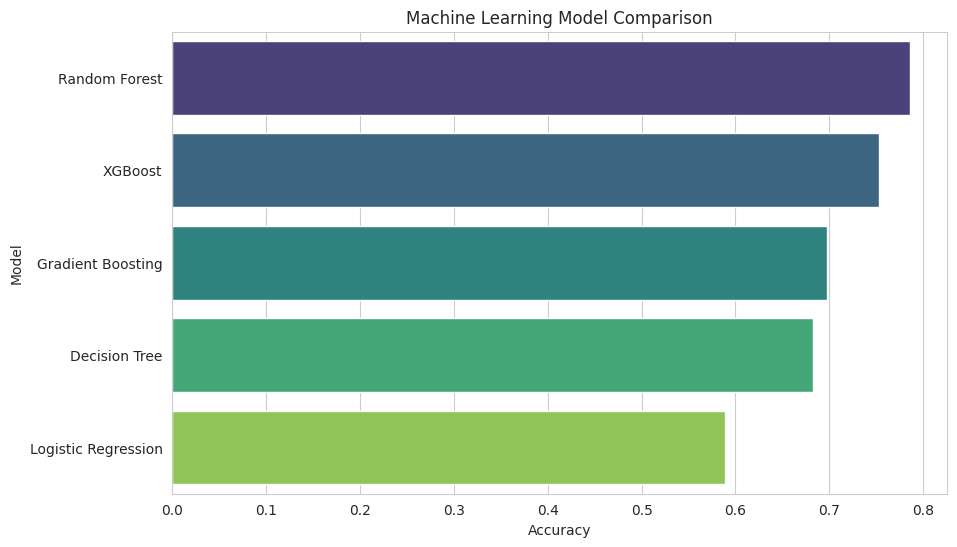

In [41]:
# ==========================================
# Accuracy Comparison
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model",

    palette="viridis"

)

plt.title("Machine Learning Model Comparison")

plt.show()

In [42]:
# ==========================================
# Cross Validation
# ==========================================

for name, model in trained_models.items():

    score = cross_val_score(

        model,

        X,

        y,

        cv=5,

        scoring="accuracy"

    )

    print()

    print(name)

    print("Average Accuracy :", score.mean())

    print("Standard Deviation :", score.std())


Logistic Regression
Average Accuracy : 0.25921
Standard Deviation : 0.04143733099513046

Decision Tree
Average Accuracy : 0.5908100000000001
Standard Deviation : 0.006779926253286256

Random Forest
Average Accuracy : 0.6885199999999999
Standard Deviation : 0.006582446353750245

Gradient Boosting
Average Accuracy : 0.6913799999999999
Standard Deviation : 0.0065236952718532165

XGBoost
Average Accuracy : 0.68857
Standard Deviation : 0.0061382896640677


In [43]:
# ==========================================
# Hyperparameter Tuning
# ==========================================

parameter_grid = {

    "n_estimators":[

        100,

        200

    ],

    "max_depth":[

        10,

        20,

        None

    ],

    "min_samples_split":[

        2,

        5

    ]

}

grid = GridSearchCV(

    RandomForestClassifier(

        random_state=42

    ),

    parameter_grid,

    cv=3,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(

    X_train,

    y_train

)

print(

    "Best Parameters :",

    grid.best_params_

)

print(

    "Best Accuracy :",

    grid.best_score_

)

Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy : 0.7725125080540108


In [44]:
# ==========================================
# Best Model
# ==========================================

best_model = grid.best_estimator_

prediction = best_model.predict(
    X_valid
)

accuracy = accuracy_score(
    y_valid,
    prediction
)

print(

    "Validation Accuracy :",

    accuracy

)

Validation Accuracy : 0.78965


In [45]:
# ==========================================
# Save Feature Encoders
# ==========================================

joblib.dump(
    encoders,
    "feature_encoders.pkl"
)

print("Feature Encoders Saved Successfully!")

# ==========================================
# Save Scaler
# ==========================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully!")

# ==========================================
# Save Target Label Encoder
# ==========================================

joblib.dump(
    label_target,
    "label_encoder.pkl"
)

print("Label Encoder Saved Successfully!")

# ==========================================
# Save Model
# ==========================================

joblib.dump(
    best_model,
    "Credit_Scoring_Model.pkl"
)

print("Model Saved Successfully!")

Feature Encoders Saved Successfully!
Scaler Saved Successfully!
Label Encoder Saved Successfully!
Model Saved Successfully!


In [46]:
# ==========================================
# Load Saved Model
# ==========================================

loaded_model = joblib.load(
    "Credit_Scoring_Model.pkl"
)

print(loaded_model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [47]:
# ==========================================
# Predict Validation Data
# ==========================================

prediction = loaded_model.predict(
    X_valid
)

prediction[:10]

array([1, 1, 1, 2, 2, 0, 2, 2, 2, 2])

In [48]:
# ==========================================
# Classification Report
# ==========================================

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(
    y_valid,
    prediction,
    target_names=label_target.classes_
))

Classification Report
              precision    recall  f1-score   support

        Good       0.75      0.71      0.73      3566
        Poor       0.78      0.80      0.79      5799
    Standard       0.81      0.81      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.77      0.78     20000
weighted avg       0.79      0.79      0.79     20000



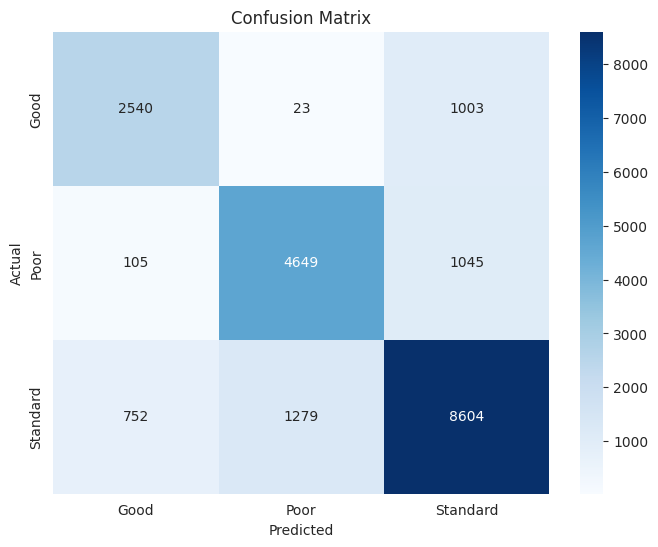

In [49]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_valid, prediction)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=label_target.classes_,
    yticklabels=label_target.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [50]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
15,Outstanding_Debt,0.107820
7,Interest_Rate,0.078482
10,Delay_from_due_date,0.067415
12,Changed_Credit_Limit,0.051139
17,Credit_History_Age,0.049352
14,Credit_Mix,0.049329
13,Num_Credit_Inquiries,0.046289
20,Amount_invested_monthly,0.045172
16,Credit_Utilization_Ratio,0.045083
3,Annual_Income,0.043962


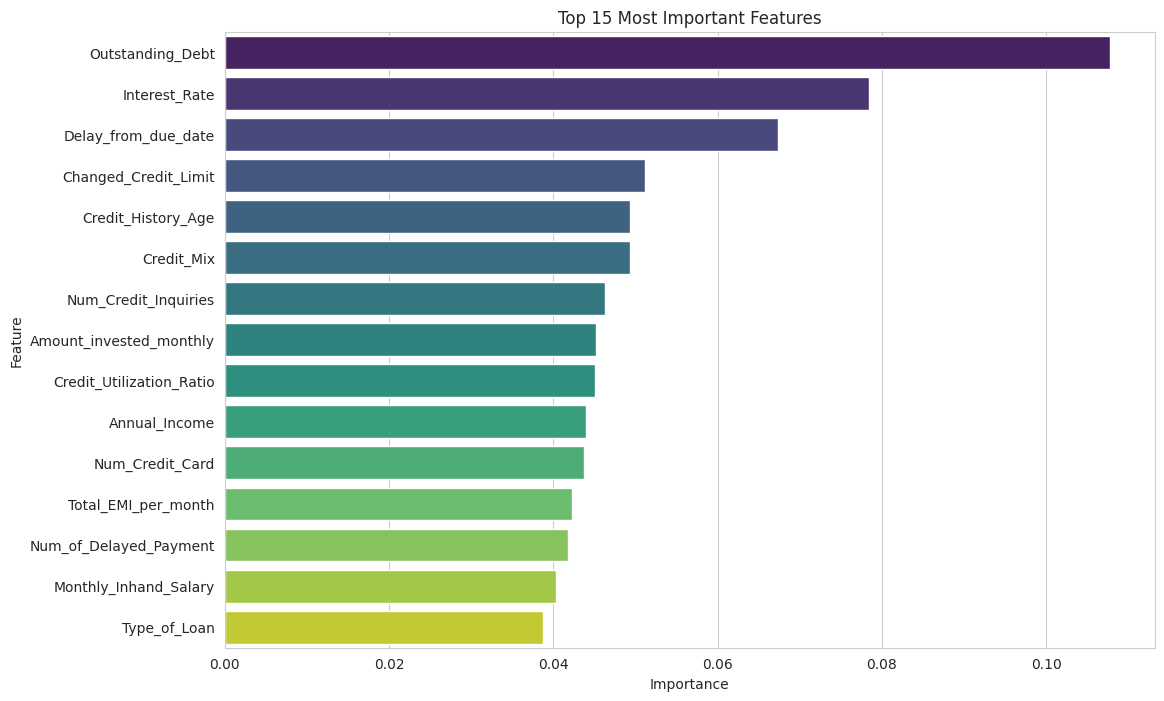

In [51]:
# ==========================================
# Feature Importance Plot
# ==========================================

plt.figure(figsize=(12,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Most Important Features")

plt.show()

In [52]:
# ==========================================
# Final Accuracy
# ==========================================

accuracy = accuracy_score(
    y_valid,
    prediction
)

precision = precision_score(
    y_valid,
    prediction,
    average="weighted"
)

recall = recall_score(
    y_valid,
    prediction,
    average="weighted"
)

f1 = f1_score(
    y_valid,
    prediction,
    average="weighted"
)

print("="*50)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.7896
Precision : 0.7893
Recall    : 0.7896
F1 Score  : 0.7894


In [53]:
# ==========================================
# Predict Test Dataset
# ==========================================

test_prediction = best_model.predict(
    X_test
)

test_prediction[:10]

array([0, 0, 0, 0, 0, 0, 2, 0, 0, 0])

In [54]:
# ==========================================
# Decode Predictions
# ==========================================

decoded_prediction = label_target.inverse_transform(
    test_prediction
)

decoded_prediction[:10]

array(['Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Standard', 'Good',
       'Good', 'Good'], dtype=object)

In [55]:
# ==========================================
# Create Prediction DataFrame
# ==========================================

submission = test_df.copy()

submission["Predicted_Credit_Score"] = decoded_prediction

submission.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Predicted_Credit_Score
0,11,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,128,...,1,809.98,35.030402,190,1,49.574949,236.642682,6,186.266702,Good
1,10,24.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,128,...,1,809.98,33.053114,181,1,49.574949,21.465380,2,361.444004,Good
2,9,24.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,128,...,1,809.98,33.811894,86,1,49.574949,148.233938,5,264.675446,Good
3,2,24.0,12,19114.12,3093.745000,3.0,4.0,3.0,4.0,128,...,1,809.98,32.430559,191,1,49.574949,39.082511,2,343.826873,Good
4,11,28.0,7,34847.84,3037.986667,2.0,4.0,6.0,1.0,684,...,1,605.03,25.926822,244,1,18.816215,39.684018,1,485.298434,Good


In [56]:
# ==========================================
# Save Prediction File
# ==========================================

submission.to_csv(

    "Credit_Score_Predictions.csv",

    index=False

)

print("Prediction File Saved Successfully!")

Prediction File Saved Successfully!


In [57]:
# ==========================================
# Download Files
# ==========================================

from google.colab import files

files.download("Credit_Score_Predictions.csv")

files.download("Credit_Scoring_Model.pkl")

files.download("scaler.pkl")

files.download("label_encoder.pkl")

files.download("feature_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
# ==========================================
# Predict One Customer
# ==========================================

sample = X_valid[0].reshape(1,-1)

prediction = best_model.predict(sample)

label = label_target.inverse_transform(prediction)

print("Predicted Credit Score :", label[0])

Predicted Credit Score : Poor


In [59]:
print("="*70)
print("Credit Scoring Model Completed Successfully")
print("="*70)

print()

print("Dataset Loaded")

print("EDA Completed")

print("Data Cleaning Completed")

print("Feature Engineering Completed")

print("Model Training Completed")

print("Hyperparameter Tuning Completed")

print("Model Evaluation Completed")

print("Model Saved")

print("Prediction Completed")

print()

print("Project Ready for Deployment")

Credit Scoring Model Completed Successfully

Dataset Loaded
EDA Completed
Data Cleaning Completed
Feature Engineering Completed
Model Training Completed
Hyperparameter Tuning Completed
Model Evaluation Completed
Model Saved
Prediction Completed

Project Ready for Deployment
